# Training ColBERT

Implement the training loop from scratch: pairwise contrastive loss, hard negatives, and in-batch negatives. Show the loss curve and a concrete before/after comparison on the toy dataset.

**Estimated runtime:** ~5-10 minutes (training on MPS/CPU)

In [1]:
%pip install torch transformers matplotlib seaborn numpy

import json
import numpy as np
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
import seaborn as sns
from transformers import AutoTokenizer, AutoModel

import sys
import os
sys.path.insert(0, os.path.join(os.path.dirname(os.path.abspath("__file__")), ".."))
from colbert_from_scratch.maxsim import maxsim_torch
from part2.model import ColBERT
from part2.training import colbert_pairwise_loss
from part2.tokenize import get_token_labels

device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
print(f"Device: {device}")


[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.
Device: mps


In [2]:
# Load model and toy dataset

tokenizer = AutoTokenizer.from_pretrained("bert-base-uncased")
bert = AutoModel.from_pretrained("bert-base-uncased")

colbert = ColBERT(bert, tokenizer, dim=128, max_query_len=32, max_doc_len=180)
colbert.to(device)

with open("../data/toy_retrieval.json") as f:
    dataset = json.load(f)

documents = {doc["id"]: doc["text"] for doc in dataset["documents"]}
queries = {q["id"]: q for q in dataset["queries"]}

print("Model loaded.")

Model loaded.


## Why training is needed

The ColBERT architecture from notebook 04 uses raw BERT embeddings plus a random projection. BERT was trained on language modeling (predicting masked words), not retrieval (ranking documents). The scores it produces are noisy, and relevant documents don't consistently outscore hard negatives.

The table below shows where the untrained model gets rankings wrong.

In [3]:
# Pre-training scores — snapshot the model's current (bad) rankings

def score_all_queries(model, dataset, _documents):
    """Score every query against every document. Returns dict of results."""
    model.eval()
    results = {}
    with torch.no_grad():
        for q in dataset["queries"]:
            q_emb = model.encode_query(q["text"])
            doc_scores = []
            for doc in dataset["documents"]:
                d_emb, _ = model.encode_document(doc["text"])
                score = maxsim_torch(q_emb, d_emb, normalize=False).item()
                doc_scores.append((doc["id"], score))
            doc_scores.sort(key=lambda x: -x[1])
            ranks = {did: r + 1 for r, (did, _) in enumerate(doc_scores)}
            results[q["id"]] = {"scores": dict(doc_scores), "ranks": ranks}
    return results


def print_rankings(results, dataset, _documents, title="Rankings"):
    """Print a formatted ranking table."""
    print(f"\n{'=' * 85}")
    print(f"  {title}")
    print(f"{'=' * 85}")
    for q in dataset["queries"]:
        r = results[q["id"]]
        print(f"\n  {q['text']}")
        for doc_id in q["relevant"] + q["hard_negative"]:
            score = r["scores"][doc_id]
            rank = r["ranks"][doc_id]
            label = "RELEVANT" if doc_id in q["relevant"] else "hard neg"
            marker = ""
            if doc_id in q["relevant"]:
                marker = " <-- CORRECT" if rank == 1 else f" <-- WRONG (rank {rank})"
            print(f"    doc {doc_id:>2} ({label:>8}): {score:>8.4f}  rank {rank}{marker}")


pre_train_results = score_all_queries(colbert, dataset, documents)
print_rankings(pre_train_results, dataset, documents, "PRE-TRAINING Rankings (untrained model)")


  PRE-TRAINING Rankings (untrained model)

  Who created the Python programming language?
    doc  0 (RELEVANT):  13.7575  rank 3 <-- WRONG (rank 3)
    doc  1 (hard neg):  12.2828  rank 7
    doc  5 (hard neg):  15.2609  rank 2
    doc  7 (hard neg):  12.8842  rank 6

  What is the longest snake species?
    doc  9 (RELEVANT):  14.0909  rank 3 <-- WRONG (rank 3)
    doc  1 (hard neg):  13.7688  rank 4
    doc  6 (hard neg):  15.0403  rank 1

  Where did the creator of Python work?
    doc  2 (RELEVANT):  13.8000  rank 1 <-- CORRECT
    doc  0 (hard neg):  12.7379  rank 3
    doc  7 (hard neg):  12.1111  rank 6

  What do machine learning models need?
    doc  3 (RELEVANT):  14.2324  rank 1 <-- CORRECT
    doc  8 (hard neg):  12.2021  rank 4

  Which programming languages are most popular?
    doc  5 (RELEVANT):  16.2910  rank 1 <-- CORRECT
    doc  0 (hard neg):  11.6653  rank 8
    doc  7 (hard neg):  12.6278  rank 5


The model assigns similar scores to relevant and irrelevant documents because BERT was trained on language modeling, not retrieval. Training tells it: for this query, this document should score higher than that one. That's the whole objective.

---

## The simplest training signal: one right answer, one wrong answer

Given a triplet (query, positive doc, negative doc):
1. Compute MaxSim(query, positive)
2. Compute MaxSim(query, negative)
3. Cross-entropy loss: positive score should win

$$L = -\log \frac{\exp(S^+)}{\exp(S^+) + \exp(S^-)}$$

In [4]:
# Worked example: the pairwise loss with actual numbers

colbert.eval()
q = dataset["queries"][0]  # "Who created the Python programming language?"

with torch.no_grad():
    q_emb = colbert.encode_query(q["text"])
    pos_emb, _ = colbert.encode_document(documents[q["relevant"][0]])  # doc 0
    neg_emb, _ = colbert.encode_document(documents[q["hard_negative"][0]])  # doc 1

pos_score = maxsim_torch(q_emb, pos_emb, normalize=False)
neg_score = maxsim_torch(q_emb, neg_emb, normalize=False)

# Manual loss calculation
scores = torch.stack([pos_score, neg_score])
probs = F.softmax(scores, dim=0)
loss = -torch.log(probs[0])

print(f"Query: \"{q['text']}\"")
print(f"Positive doc {q['relevant'][0]}: \"{documents[q['relevant'][0]][:60]}...\"")
print(f"Negative doc {q['hard_negative'][0]}: \"{documents[q['hard_negative'][0]][:60]}...\"")
print(f"\nMaxSim(q, pos): {pos_score.item():.4f}")
print(f"MaxSim(q, neg): {neg_score.item():.4f}")
print(f"Gap:            {(pos_score - neg_score).item():+.4f}")
print(f"\nP(positive wins): {probs[0].item():.4f}")
print(f"P(negative wins): {probs[1].item():.4f}")
print(f"Loss: {loss.item():.4f}")
print(f"\nRandom baseline loss (P=0.5): {-np.log(0.5):.4f}")
print("Perfect loss (P≈1.0):          ~0.0000")

Query: "Who created the Python programming language?"
Positive doc 0: "The python programming language was created by Guido van Ros..."
Negative doc 1: "The python snake is a large non-venomous reptile found in tr..."

MaxSim(q, pos): 13.7575
MaxSim(q, neg): 12.2828
Gap:            +1.4747

P(positive wins): 0.8138
P(negative wins): 0.1862
Loss: 0.2061

Random baseline loss (P=0.5): 0.6931
Perfect loss (P≈1.0):          ~0.0000


## Where negatives come from

Random negatives: any document that isn't the answer. Easy for the model to distinguish, weak training signal.

Hard negatives (BM25-mined): top BM25 results that aren't labeled relevant. They share surface keywords with the query, which makes them much harder to distinguish. ColBERTv1 used these. Our toy dataset has hand-crafted hard negatives.

In [5]:
# Show the hard negatives for each query — why they're "hard"

for q in dataset["queries"]:
    print(f"\nQuery: \"{q['text']}\"")
    print(f"  Relevant doc {q['relevant'][0]}: \"{documents[q['relevant'][0]][:80]}...\"")
    for neg_id in q["hard_negative"]:
        print(f"  Hard neg  doc {neg_id}: \"{documents[neg_id][:80]}...\"")
    print(f"  Note: {q['note']}")


Query: "Who created the Python programming language?"
  Relevant doc 0: "The python programming language was created by Guido van Rossum in 1991. It was ..."
  Hard neg  doc 1: "The python snake is a large non-venomous reptile found in tropical regions. Pyth..."
  Hard neg  doc 5: "Java and Python are the most popular programming languages in 2024, according to..."
  Hard neg  doc 7: "Python emphasizes code readability and uses significant whitespace. Its design p..."
  Note: Requires matching 'python' + 'programming' + 'created'. Bi-encoder may confuse with snake docs or other Python-mention docs.

Query: "What is the longest snake species?"
  Relevant doc 9: "The reticulated python is the longest snake species in the world, with some indi..."
  Hard neg  doc 1: "The python snake is a large non-venomous reptile found in tropical regions. Pyth..."
  Hard neg  doc 6: "The anaconda is another large snake species native to South America. Unlike pyth..."
  Note: Requires matching 'longest

## In-batch negatives: getting more signal for free

With batch size B, each positive document also serves as a negative for all other queries in the batch. The B x B score matrix should be high on the diagonal, low everywhere else. This gives B-1 extra negatives per query for free.

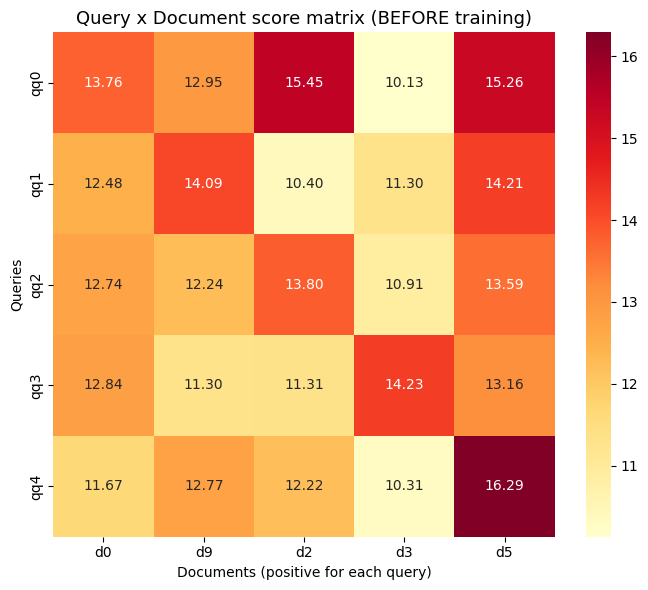

Goal: bright diagonal, dark off-diagonal. Currently too uniform.


In [6]:
# Visualize the B x B score matrix before training

colbert.eval()
B = len(dataset["queries"])

query_texts = [q["text"] for q in dataset["queries"]]
pos_doc_texts = [documents[q["relevant"][0]] for q in dataset["queries"]]

with torch.no_grad():
    q_embs = [colbert.encode_query(t) for t in query_texts]
    d_embs = [colbert.encode_document(t)[0] for t in pos_doc_texts]

# Build score matrix
scores_matrix = torch.zeros(B, B)
for i in range(B):
    for j in range(B):
        scores_matrix[i, j] = maxsim_torch(q_embs[i], d_embs[j], normalize=False).item()

fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(scores_matrix.cpu().numpy(), ax=ax, annot=True, fmt=".2f",
            xticklabels=[f"d{q['relevant'][0]}" for q in dataset["queries"]],
            yticklabels=[f"q{q['id']}" for q in dataset["queries"]],
            cmap="YlOrRd")
ax.set_title("Query x Document score matrix (BEFORE training)", fontsize=13)
ax.set_xlabel("Documents (positive for each query)")
ax.set_ylabel("Queries")
plt.tight_layout()
plt.show()

print("Goal: bright diagonal, dark off-diagonal. Currently too uniform.")

## The training loop

Most of BERT is frozen. Only the top 4 transformer layers and the projection are trained. This keeps training fast and prevents catastrophic forgetting of BERT's language knowledge.

In [7]:
# Build training triples from the toy dataset
# We use ALL non-relevant documents as negatives for each query, not just
# the hand-picked hard negatives. With only 10 documents, the model needs
# to learn that the positive should outscore every other document — not just
# the 1-3 hard negatives. (Real ColBERT trains on MS MARCO with millions of
# negatives; our toy dataset needs full coverage.)

all_doc_ids = {doc["id"] for doc in dataset["documents"]}

triples = []
for q in dataset["queries"]:
    pos_text = documents[q["relevant"][0]]
    neg_ids = all_doc_ids - set(q["relevant"])
    for neg_id in neg_ids:
        triples.append((q["text"], pos_text, documents[neg_id]))

print(f"Training triples: {len(triples)} (5 queries x 9 negatives each)")
print("\nExample triples for q0:")
for i, (q, p, n) in enumerate(triples[:3]):
    print(f"  Triple {i}: neg=\"{n[:60]}...\"")

Training triples: 45 (5 queries x 9 negatives each)

Example triples for q0:
  Triple 0: neg="The python snake is a large non-venomous reptile found in tr..."
  Triple 1: neg="Guido van Rossum, the creator of Python, worked at Google an..."
  Triple 2: neg="Machine learning models require large datasets for training...."


In [8]:
# Freeze BERT, unfreeze top 4 layers + projection
colbert.freeze_bert(n_unfreeze_layers=4)

optimizer = torch.optim.AdamW(
    [p for p in colbert.parameters() if p.requires_grad],
    lr=1e-5,
)

print(f"\nTrainable parameters: {sum(p.numel() for p in colbert.parameters() if p.requires_grad):,}")
print(f"Frozen parameters:    {sum(p.numel() for p in colbert.parameters() if not p.requires_grad):,}")

Frozen: 135 params, Trainable: 65 params

Trainable parameters: 28,449,792
Frozen parameters:    81,130,752


In [9]:
# Training loop
import random

n_epochs = 20
losses = []

for epoch in range(n_epochs):
    colbert.train()
    epoch_loss = 0.0
    random.shuffle(triples)

    for query, pos_doc, neg_doc in triples:
        q_emb = colbert.encode_query(query)
        pos_emb, _ = colbert.encode_document(pos_doc)
        neg_emb, _ = colbert.encode_document(neg_doc)

        loss = colbert_pairwise_loss(q_emb, pos_emb, neg_emb)
        loss.backward()
        optimizer.step()
        optimizer.zero_grad()
        epoch_loss += loss.item()

    avg_loss = epoch_loss / len(triples)
    losses.append(avg_loss)
    if (epoch + 1) % 5 == 0 or epoch == 0:
        print(f"Epoch {epoch + 1:>2}/{n_epochs}  loss: {avg_loss:.4f}")

print("\nTraining complete.")

Epoch  1/20  loss: 0.2491
Epoch  5/20  loss: 0.0132
Epoch 10/20  loss: 0.0020
Epoch 15/20  loss: 0.0008
Epoch 20/20  loss: 0.0006

Training complete.


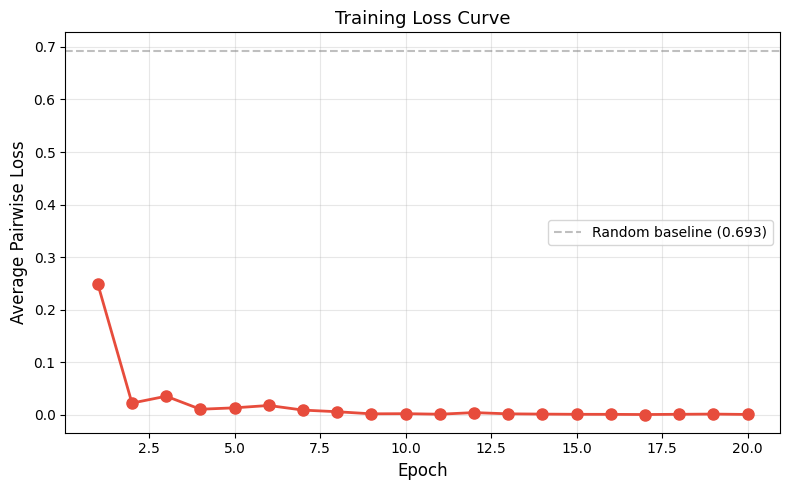

In [10]:
# Plot the training loss curve

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(range(1, n_epochs + 1), losses, "o-", color="#e74c3c", linewidth=2, markersize=8)
ax.set_xlabel("Epoch", fontsize=12)
ax.set_ylabel("Average Pairwise Loss", fontsize=12)
ax.set_title("Training Loss Curve", fontsize=13)
ax.axhline(y=-np.log(0.5), color="gray", linestyle="--", alpha=0.5, label="Random baseline (0.693)")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
fig.savefig("../figures/05_loss_curve.png", dpi=150, bbox_inches="tight")
plt.show()

---

## Before vs after

The same ranking table from before training, now with the trained model. Which rankings flipped? What are the score deltas?

In [ ]:
# Post-training rankings

post_train_results = score_all_queries(colbert, dataset, documents)
print_rankings(post_train_results, dataset, documents, "POST-TRAINING Rankings (trained model)")

print(f"\n{'=' * 85}")
print("  COMPARISON")
print(f"{'=' * 85}")
for q in dataset["queries"]:
    pre = pre_train_results[q["id"]]
    post = post_train_results[q["id"]]
    rel_id = q["relevant"][0]
    pre_rank = pre["ranks"][rel_id]
    post_rank = post["ranks"][rel_id]
    pre_score = pre["scores"][rel_id]
    post_score = post["scores"][rel_id]
    status = "FIXED" if post_rank < pre_rank else ("same" if post_rank == pre_rank else "WORSE")
    if pre_rank == 1 and post_rank == 1:
        status = "kept"
    print(f"  {q['id']}: rank {pre_rank} -> {post_rank}  score {pre_score:.4f} -> {post_score:.4f}  [{status}]")


  POST-TRAINING Rankings (trained model)

  Who created the Python programming language?
    doc  0 (RELEVANT):  23.2343  rank 1 <-- CORRECT
    doc  1 (hard neg):   2.7438  rank 9
    doc  5 (hard neg):  12.6011  rank 3
    doc  7 (hard neg):  12.3510  rank 4

  What is the longest snake species?
    doc  9 (RELEVANT):  19.5137  rank 1 <-- CORRECT
    doc  1 (hard neg):  10.1433  rank 4
    doc  6 (hard neg):  10.8897  rank 3

  Where did the creator of Python work?
    doc  2 (RELEVANT):  19.6214  rank 1 <-- CORRECT
    doc  0 (hard neg):  11.1031  rank 2
    doc  7 (hard neg):   7.2202  rank 6

  What do machine learning models need?
    doc  3 (RELEVANT):  22.4809  rank 1 <-- CORRECT
    doc  8 (hard neg):   8.5290  rank 6

  Which programming languages are most popular?
    doc  5 (RELEVANT):  21.1789  rank 1 <-- CORRECT
    doc  0 (hard neg):   9.2922  rank 6
    doc  7 (hard neg):   8.1080  rank 7

  COMPARISON
  q0: rank 3 -> 1  score 13.7575 -> 23.2343  [FIXED]
  q1: rank 3 -

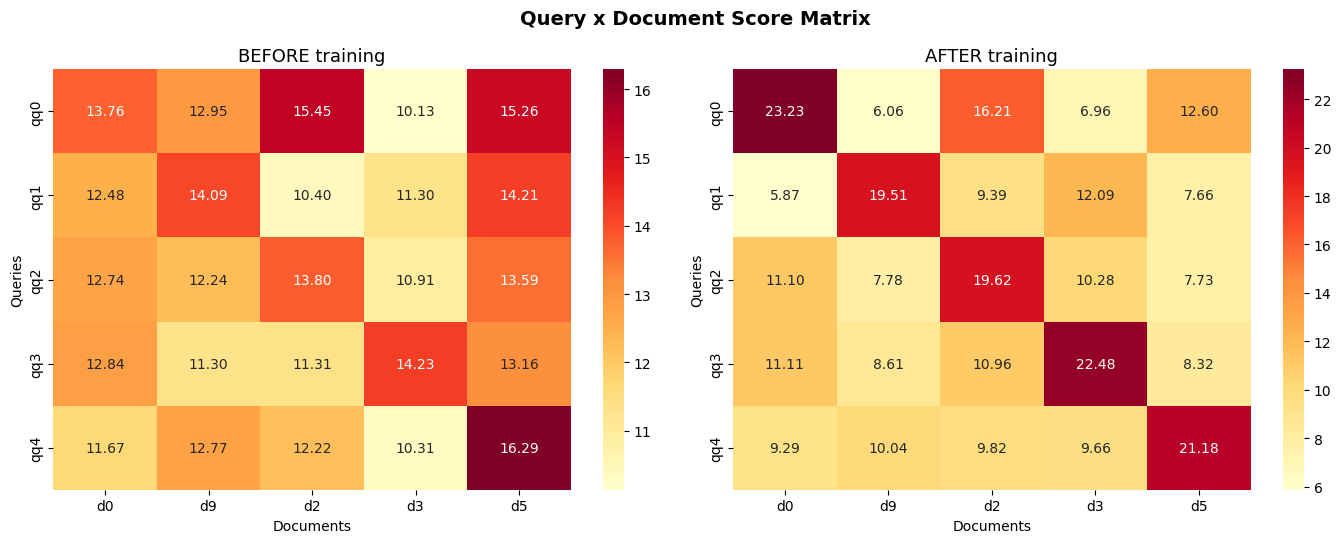

After training: diagonal should be brighter, off-diagonal darker.


In [12]:
# Before/after B x B score matrix

colbert.eval()
with torch.no_grad():
    q_embs_post = [colbert.encode_query(t) for t in query_texts]
    d_embs_post = [colbert.encode_document(t)[0] for t in pos_doc_texts]

scores_post = torch.zeros(B, B)
for i in range(B):
    for j in range(B):
        scores_post[i, j] = maxsim_torch(q_embs_post[i], d_embs_post[j], normalize=False).item()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5.5))

q_labels = [f"q{q['id']}" for q in dataset["queries"]]
d_labels = [f"d{q['relevant'][0]}" for q in dataset["queries"]]

sns.heatmap(scores_matrix.cpu().numpy(), ax=ax1, annot=True, fmt=".2f",
            xticklabels=d_labels, yticklabels=q_labels, cmap="YlOrRd")
ax1.set_title("BEFORE training", fontsize=13)
ax1.set_xlabel("Documents")
ax1.set_ylabel("Queries")

sns.heatmap(scores_post.cpu().numpy(), ax=ax2, annot=True, fmt=".2f",
            xticklabels=d_labels, yticklabels=q_labels, cmap="YlOrRd")
ax2.set_title("AFTER training", fontsize=13)
ax2.set_xlabel("Documents")
ax2.set_ylabel("Queries")

fig.suptitle("Query x Document Score Matrix", fontsize=14, fontweight="bold")
plt.tight_layout()
fig.savefig("../figures/05_score_matrix_before_after.png", dpi=150, bbox_inches="tight")
plt.show()

print("After training: diagonal should be brighter, off-diagonal darker.")

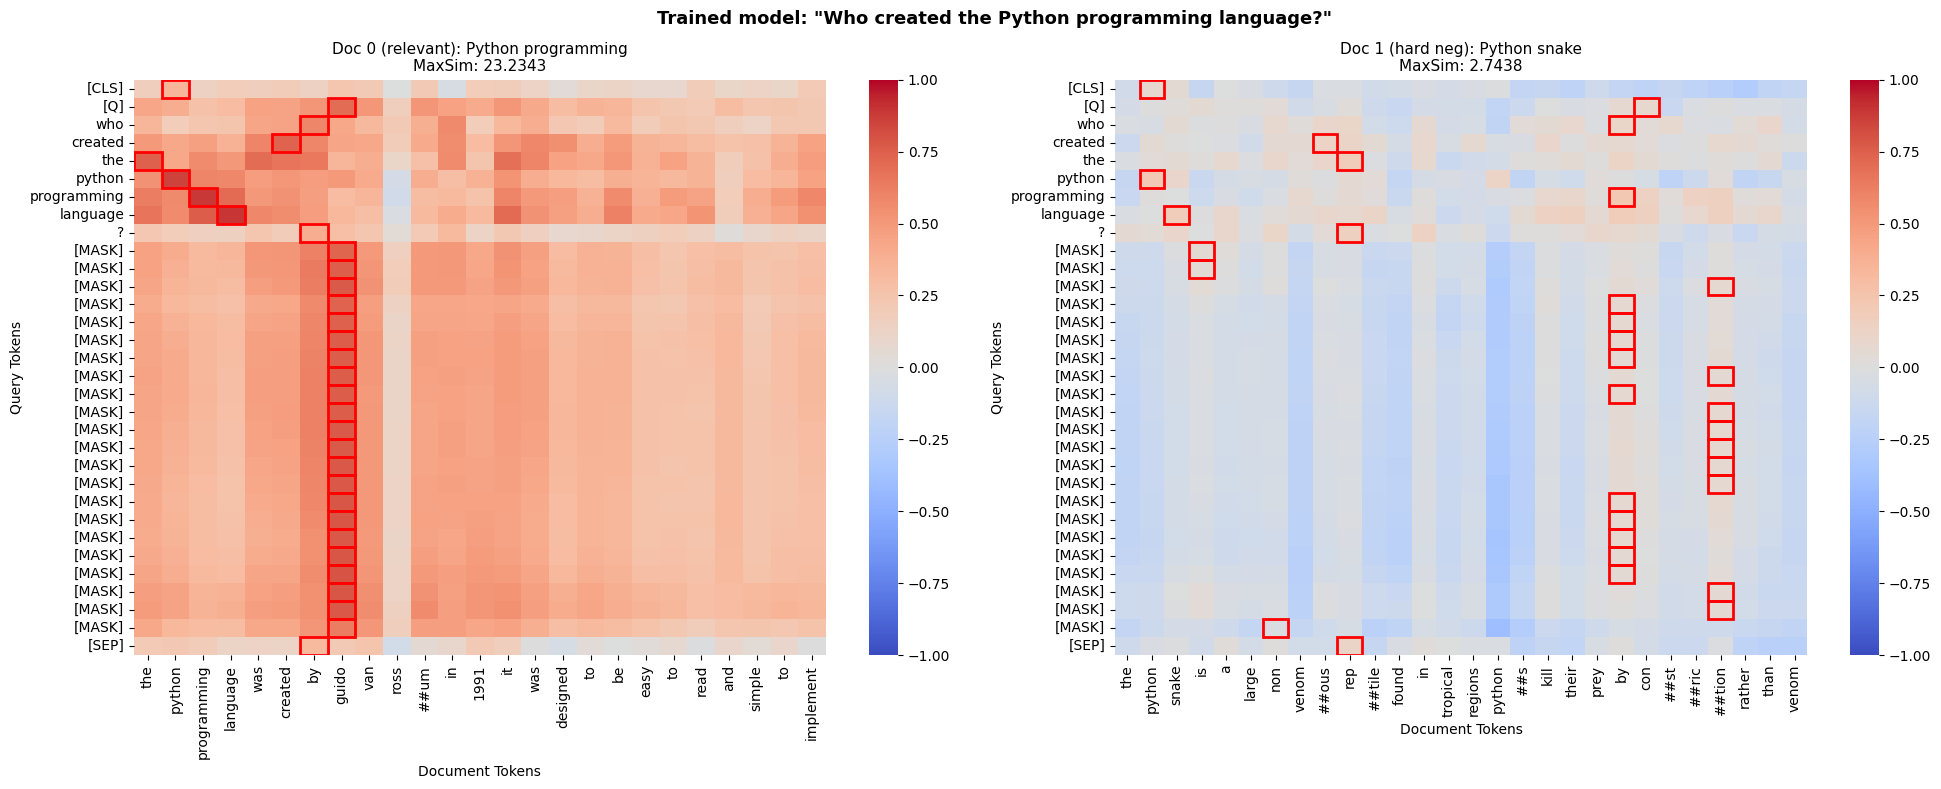

In [13]:
# Before/after MaxSim heatmap for the disambiguation query (q0 vs doc 0 and doc 1)
# Re-encode with the trained model

q0 = dataset["queries"][0]

colbert.eval()
with torch.no_grad():
    q_emb_trained = colbert.encode_query(q0["text"])
    d0_emb_trained, d0_tok_trained = colbert.encode_document(documents[0])
    d1_emb_trained, d1_tok_trained = colbert.encode_document(documents[1])

q_labels_trained = get_token_labels(q0["text"], tokenizer, mode="query")

fig, axes = plt.subplots(1, 2, figsize=(20, 8))

for ax, d_emb, d_toks, title in [
    (axes[0], d0_emb_trained, d0_tok_trained, "Doc 0 (relevant): Python programming"),
    (axes[1], d1_emb_trained, d1_tok_trained, "Doc 1 (hard neg): Python snake"),
]:
    q_np = q_emb_trained.cpu().numpy()
    d_np = d_emb.cpu().numpy() if isinstance(d_emb, torch.Tensor) else d_emb
    sim = q_np @ d_np.T  # already normalized

    sns.heatmap(sim, ax=ax, xticklabels=d_toks, yticklabels=q_labels_trained,
                cmap="coolwarm", center=0, vmin=-1, vmax=1)
    for i, j in enumerate(sim.argmax(axis=1)):
        ax.add_patch(plt.Rectangle((j, i), 1, 1, fill=False, edgecolor="red", linewidth=2))
    score = sim.max(axis=1).sum()
    ax.set_title(f"{title}\nMaxSim: {score:.4f}", fontsize=11)
    ax.set_xlabel("Document Tokens")
    ax.set_ylabel("Query Tokens")

fig.suptitle(f'Trained model: "{q0["text"]}"', fontsize=13, fontweight="bold")
plt.tight_layout()
fig.savefig("../figures/05_heatmap_trained.png", dpi=150, bbox_inches="tight")
plt.show()

---

## Why MaxSim is a good loss surface

The `max` in MaxSim passes gradients only through the argmax index. For each query token, only the document token it matched best gets a gradient. Everything else gets zero. So the model learns to sharpen its best matches rather than averaging across all pairs.

In [14]:
# Demonstrate sparse gradient flow through MaxSim

Q = torch.randn(8, 128, requires_grad=True)
D = torch.randn(20, 128, requires_grad=True)

# Forward: MaxSim
sim = Q @ D.T                          # (8, 20)
max_per_row = sim.max(dim=1).values     # (8,)
score = max_per_row.sum()               # scalar

# Backward
score.backward()

# Check gradient sparsity in D
d_grad_nonzero = (D.grad.abs() > 1e-8).any(dim=1).sum().item()
d_grad_total = D.shape[0]

print(f"Q shape: {Q.shape}  (8 query tokens, 128 dims)")
print(f"D shape: {D.shape}  (20 document tokens, 128 dims)")
print(f"\nD.grad non-zero rows: {d_grad_nonzero} / {d_grad_total}")
print(f"D.grad zero rows:     {d_grad_total - d_grad_nonzero} / {d_grad_total}")
print(f"\nOnly {d_grad_nonzero} document tokens received any gradient.")
print("The rest are invisible to the loss — MaxSim ignores them completely.")
print("This sparsity is why training converges fast: the model focuses")
print("all its gradient budget on sharpening the best matches.")

Q shape: torch.Size([8, 128])  (8 query tokens, 128 dims)
D shape: torch.Size([20, 128])  (20 document tokens, 128 dims)

D.grad non-zero rows: 7 / 20
D.grad zero rows:     13 / 20

Only 7 document tokens received any gradient.
The rest are invisible to the loss — MaxSim ignores them completely.
This sparsity is why training converges fast: the model focuses
all its gradient budget on sharpening the best matches.


---

## ColBERTv2 distillation (conceptual)

ColBERTv2 replaces the simple contrastive loss with knowledge distillation from a cross-encoder teacher. A cross-encoder scores query-document pairs jointly (concatenated input to BERT), which is more accurate but too slow for retrieval. The trained cross-encoder reranks the top ~500 BM25 results per query, producing soft relevance scores. ColBERT then trains to match these soft scores via KL divergence.

The code change is small. The loss function swaps from cross-entropy to KL divergence:

In [15]:
# ColBERTv2 distillation loss — the entire training-loop change

from part2.training import distillation_loss

# Example: student (ColBERT) and teacher (cross-encoder) score 4 documents
student_scores = torch.tensor([3.2, 1.1, 0.8, 0.3])  # ColBERT's MaxSim scores
teacher_scores = torch.tensor([4.5, 1.8, 0.5, 0.1])  # cross-encoder's reranking scores

loss = distillation_loss(student_scores, teacher_scores, temperature=1.0)

print("Student scores:", student_scores.tolist())
print("Teacher scores:", teacher_scores.tolist())
print()
print("Student probs:", F.softmax(student_scores, dim=0).tolist())
print("Teacher probs:", F.softmax(teacher_scores, dim=0).tolist())
print(f"\nDistillation loss: {loss.item():.4f}")
print("\nThe student learns to match the teacher's ranking distribution,")
print("not just which document is #1. This transfers nuanced relevance judgments.")

Student scores: [3.200000047683716, 1.100000023841858, 0.800000011920929, 0.30000001192092896]
Teacher scores: [4.5, 1.7999999523162842, 0.5, 0.10000000149011612]

Student probs: [0.7885206937789917, 0.09655943512916565, 0.0715329721570015, 0.04338694363832474]
Teacher probs: [0.91091388463974, 0.06121843308210373, 0.016683969646692276, 0.011183598078787327]

Distillation loss: 0.0160

The student learns to match the teacher's ranking distribution,
not just which document is #1. This transfers nuanced relevance judgments.


Full distillation requires a trained cross-encoder reranking top-500 passages per query, which is out of scope here. The code above is the only change to the training loop. Part 3 covers residual compression, the other big ColBERTv2 upgrade.

---

## Save checkpoint

Save the trained model for notebook 06.

In [16]:
# Save checkpoint for notebook 06
import os
os.makedirs("../checkpoints", exist_ok=True)

checkpoint = {
    "model_state_dict": colbert.state_dict(),
    "optimizer_state_dict": optimizer.state_dict(),
    "losses": losses,
    "n_epochs": n_epochs,
}
torch.save(checkpoint, "../checkpoints/colbert_toy_trained.pt")
print("Checkpoint saved to ../checkpoints/colbert_toy_trained.pt")

Checkpoint saved to ../checkpoints/colbert_toy_trained.pt


---

## Training on real data: MS MARCO

The toy dataset proved that the training loop works. But 10 documents and 45 triples aren't enough for the model to learn corpus-level behaviors like IDF weighting or `[MASK]` clustering. Those require seeing thousands of query-document pairs across diverse topics.

MS MARCO is the standard training dataset for ColBERT. It has ~8.8M passages and ~500K training queries, each with ~10 candidate passages labeled as relevant or not. We take a 30,000-query slice (~90K triples) and train for 4 epochs. Takes about 7 hours on MPS.

In [ ]:
%pip install datasets

from datasets import load_dataset

# Stream MS MARCO v1.1 - only downloads what we need, no full dataset in memory
msmarco = load_dataset("microsoft/ms_marco", "v1.1", split="train", streaming=True)

# Build triples: (query, positive_passage, hard_negative_passage)
msmarco_triples = []
n_queries = 0

for sample in msmarco:
    if n_queries >= 30_000:
        break

    passages = sample["passages"]
    pos_indices = [i for i, s in enumerate(passages["is_selected"]) if s == 1]
    neg_indices = [i for i, s in enumerate(passages["is_selected"]) if s == 0]

    if not pos_indices or not neg_indices:
        continue

    query = sample["query"]
    pos_text = passages["passage_text"][pos_indices[0]]

    # Use up to 3 hard negatives per query (BM25-retrieved but not relevant)
    for neg_idx in neg_indices[:3]:
        neg_text = passages["passage_text"][neg_idx]
        msmarco_triples.append((query, pos_text, neg_text))

    n_queries += 1
    if n_queries % 5000 == 0:
        print(f"  {n_queries} queries processed, {len(msmarco_triples)} triples so far...")

print(f"\nBuilt {len(msmarco_triples)} triples from {n_queries} queries")
print("\nExample:")
print(f"  Query: \"{msmarco_triples[0][0]}\"")
print(f"  Pos:   \"{msmarco_triples[0][1][:80]}...\"")
print(f"  Neg:   \"{msmarco_triples[0][2][:80]}...\"")


[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.
  5000 queries processed, 14969 triples so far...
  10000 queries processed, 29941 triples so far...
  15000 queries processed, 44919 triples so far...
  20000 queries processed, 59893 triples so far...
  25000 queries processed, 74869 triples so far...
  30000 queries processed, 89844 triples so far...

Built 89844 triples from 30000 queries

Example:
  Query: "what is rba"
  Pos:   "Results-Based Accountability® (also known as RBA) is a disciplined way of thinki..."
  Neg:   "Since 2007, the RBA's outstanding reputation has been affected by the 'Securency..."


In [18]:
# Fresh model for MS MARCO training
from transformers import AutoTokenizer, AutoModel
from part2.model import ColBERT

tokenizer_msmarco = AutoTokenizer.from_pretrained("bert-base-uncased")
bert_msmarco = AutoModel.from_pretrained("bert-base-uncased")
colbert_msmarco = ColBERT(bert_msmarco, tokenizer_msmarco, dim=128, max_query_len=32, max_doc_len=180)
colbert_msmarco.to(device)
colbert_msmarco.freeze_bert(n_unfreeze_layers=4)

optimizer_msmarco = torch.optim.AdamW(
    [p for p in colbert_msmarco.parameters() if p.requires_grad],
    lr=3e-5,
)

print(f"Ready to train on {len(msmarco_triples)} triples")

Frozen: 135 params, Trainable: 65 params
Ready to train on 89844 triples


In [19]:
# Training on MS MARCO with gradient accumulation
# Single-triple gradients are too noisy. Accumulating over 8 triples
# before each optimizer step gives a much cleaner gradient direction.

import random
import time

n_epochs_msmarco = 4
accumulation_steps = 8
msmarco_losses = []
step = 0
opt_step = 0
start_time = time.time()

for epoch in range(n_epochs_msmarco):
    colbert_msmarco.train()
    epoch_loss = 0.0
    random.shuffle(msmarco_triples)
    optimizer_msmarco.zero_grad()

    for i, (query, pos_doc, neg_doc) in enumerate(msmarco_triples):
        q_emb = colbert_msmarco.encode_query(query)
        pos_emb, _ = colbert_msmarco.encode_document(pos_doc)
        neg_emb, _ = colbert_msmarco.encode_document(neg_doc)

        loss = colbert_pairwise_loss(q_emb, pos_emb, neg_emb) / accumulation_steps
        loss.backward()
        epoch_loss += loss.item() * accumulation_steps
        step += 1

        if step % accumulation_steps == 0:
            optimizer_msmarco.step()
            optimizer_msmarco.zero_grad()
            opt_step += 1

        if step % 5000 == 0:
            elapsed = time.time() - start_time
            avg = epoch_loss / (i + 1)
            print(f"  step {step:>6}  opt_step {opt_step:>5}  epoch {epoch+1}  loss={avg:.4f}  elapsed={elapsed/60:.1f}min")

    # Handle remaining gradients
    if step % accumulation_steps != 0:
        optimizer_msmarco.step()
        optimizer_msmarco.zero_grad()

    avg_loss = epoch_loss / len(msmarco_triples)
    msmarco_losses.append(avg_loss)
    elapsed = time.time() - start_time
    print(f"Epoch {epoch+1}/{n_epochs_msmarco}  loss={avg_loss:.4f}  elapsed={elapsed/60:.1f}min")

print(f"\nDone. Total time: {(time.time() - start_time)/60:.1f} min")

  step   5000  opt_step   625  epoch 1  loss=0.6520  elapsed=6.7min
  step  10000  opt_step  1250  epoch 1  loss=0.6303  elapsed=13.0min
  step  15000  opt_step  1875  epoch 1  loss=0.6119  elapsed=19.2min
  step  20000  opt_step  2500  epoch 1  loss=0.5980  elapsed=25.5min
  step  25000  opt_step  3125  epoch 1  loss=0.5863  elapsed=32.2min
  step  30000  opt_step  3750  epoch 1  loss=0.5793  elapsed=38.8min
  step  35000  opt_step  4375  epoch 1  loss=0.5731  elapsed=45.5min
  step  40000  opt_step  5000  epoch 1  loss=0.5661  elapsed=52.1min
  step  45000  opt_step  5625  epoch 1  loss=0.5592  elapsed=58.3min
  step  50000  opt_step  6250  epoch 1  loss=0.5537  elapsed=64.4min
  step  55000  opt_step  6875  epoch 1  loss=0.5493  elapsed=71.8min
  step  60000  opt_step  7500  epoch 1  loss=0.5447  elapsed=80.1min
  step  65000  opt_step  8125  epoch 1  loss=0.5388  elapsed=86.4min
  step  70000  opt_step  8750  epoch 1  loss=0.5351  elapsed=92.7min
  step  75000  opt_step  9375  epoc

In [ ]:
# Save MS MARCO checkpoint for notebook 06
msmarco_checkpoint = {
    "model_state_dict": colbert_msmarco.state_dict(),
    "losses": msmarco_losses,
    "n_epochs": n_epochs_msmarco,
    "n_triples": len(msmarco_triples),
    "n_queries": n_queries,
}
torch.save(msmarco_checkpoint, "../checkpoints/colbert_msmarco_trained.pt")
print("Saved to ../checkpoints/colbert_msmarco_trained.pt")
print(f"  {n_queries} queries, {len(msmarco_triples)} triples, {n_epochs_msmarco} epochs")
print(f"  Final loss: {msmarco_losses[-1]:.4f}")

Saved to ../checkpoints/colbert_msmarco_trained.pt
  30000 queries, 89844 triples, 4 epochs
  Final loss: 0.1390


## What we learned

1. Training is simple. The loss function is one line of cross-entropy over two MaxSim scores: "positive should outscore negative."

2. Hard negatives matter. Documents that share surface keywords with the query but aren't relevant provide the strongest training signal. Random negatives are too easy.

3. Gradient sparsity is a feature. MaxSim's `max` operator passes gradients only through the argmax positions, focusing learning on the best matches rather than averaging across all token pairs.

4. The B x B score matrix tells the story. Before training: uniform scores. After training: bright diagonal, dark off-diagonal. The model learned to separate each query's relevant document from the rest.

Next up: notebook 06 looks inside the trained model to see what it learned, and finds that it reinvented classical IR.